# Plantilla Modelado y evaluación de los datos — House Prices

**Objetivo:** Construir, entrenar e interpretar modelos de aprendizaje automático utilizando los datos preparados, y evaluar su desempeño para seleccionar la mejor alternativa.

> Se conserva la estructura de la plantilla original (**1 a 7**). Al final se agregan dos apartados complementarios: **8. Experimento de crisis 2008–2010** y **9. Generación del submission de Kaggle**.

**Archivos de entrada esperados en Colab:**
- `train_clean.csv`
- `test_clean.csv`

Estos archivos ya pertenecen a la etapa anterior de **Preparación de los datos**. En este notebook **no se vuelve a hacer la limpieza**. La versión limpia utilizada aquí:

- elimina del entrenamiento los 2 outliers de `GrLivArea > 4000` con precio anormalmente bajo;
- corrige el valor imposible `GarageYrBlt = 2207` del conjunto oficial de prueba;
- trata los valores faltantes;
- elimina `GarageArea` y `TotRmsAbvGrd`, tal como se justificó por multicolinealidad;
- construye `Edad_Casa`, `Area_Total_Construida`, `Total_Banos` y `Es_Remodelada`;
- agrega `Log_SalePrice` únicamente al conjunto de entrenamiento.

El resultado es `train_clean.csv` con **1,458 filas** y `test_clean.csv` con **1,459 filas**, ambos sin valores nulos.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (
    train_test_split, KFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score, make_scorer
)
from sklearn.base import clone

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

# Datos ya limpios en la etapa de Preparación
df = pd.read_csv("train_clean.csv")
df_test_kaggle = pd.read_csv("test_clean.csv")

print("Train limpio:", df.shape)
print("Test limpio:", df_test_kaggle.shape)
print("NaN en train:", df.isna().sum().sum())
print("NaN en test:", df_test_kaggle.isna().sum().sum())

df.head()


Train limpio: (1458, 84)
Test limpio: (1459, 82)
NaN en train: 0
NaN en test: 0


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,SalePrice,Edad_Casa,Area_Total_Construida,Total_Banos,Es_Remodelada,Log_SalePrice
0,1,60,RL,65.0,8450,Pave,SinCaracteristica,Reg,Lvl,AllPub,...,2,2008,WD,Normal,208500,5,2566,3.5,0,12.247699
1,2,20,RL,80.0,9600,Pave,SinCaracteristica,Reg,Lvl,AllPub,...,5,2007,WD,Normal,181500,31,2524,2.5,0,12.109016
2,3,60,RL,68.0,11250,Pave,SinCaracteristica,IR1,Lvl,AllPub,...,9,2008,WD,Normal,223500,7,2706,3.5,1,12.317171
3,4,70,RL,60.0,9550,Pave,SinCaracteristica,IR1,Lvl,AllPub,...,2,2006,WD,Abnorml,140000,91,2473,2.0,1,11.849405
4,5,60,RL,84.0,14260,Pave,SinCaracteristica,IR1,Lvl,AllPub,...,12,2008,WD,Normal,250000,8,3343,3.5,0,12.429220


### Datos de entrada y formateo previo al modelado

La separación entre limpieza y modelado queda explícita:

1. `train.csv` / `test.csv` originales  
2. **Preparación de datos** → `train_clean.csv` / `test_clean.csv`  
3. **Este notebook** → separación train/test, formateo para los algoritmos, entrenamiento y evaluación.

Aquí solo se realizan transformaciones necesarias para que los algoritmos puedan trabajar:

- `Id` se conserva únicamente para el submission y se excluye de los predictores.
- `MSSubClass` y `MoSold` son códigos/categorías aunque parezcan números, por lo que se tratan como texto.
- Se aplica `log1p()` a `LotArea`, `GrLivArea`, `TotalBsmtSF` y `MasVnrArea`, tal como se planteó en la etapa de preparación, para reducir su asimetría.
- **One-Hot Encoding** convierte las variables categóricas en columnas 0/1.
- **StandardScaler** estandariza las variables numéricas.

El One-Hot Encoding y el escalado se encapsulan en un `Pipeline`. Conceptualmente corresponden al formateo de datos, pero sus parámetros se ajustan **solo con el conjunto de entrenamiento** (y dentro de cada fold de validación), evitando *data leakage*. De esta forma se respeta el orden de la metodología sin permitir que información del conjunto de prueba influya en el entrenamiento.


In [2]:
# Copias para no modificar los archivos originales cargados
df_model = df.copy()
test_model = df_test_kaggle.copy()

# Variables que son categorías aunque estén almacenadas como números
for data in [df_model, test_model]:
    for col in ["MSSubClass", "MoSold"]:
        data[col] = data[col].astype(str)

# Transformación logarítmica propuesta en el documento.
# log1p(x) = log(1+x), por lo que también funciona cuando x = 0.
log_features = ["LotArea", "GrLivArea", "TotalBsmtSF", "MasVnrArea"]
for data in [df_model, test_model]:
    for col in log_features:
        data[col] = np.log1p(data[col].clip(lower=0))

# Id no es predictor, pero se guarda para el submission.
ids_test = test_model["Id"].copy()

# Variable objetivo en escala logarítmica
X = df_model.drop(columns=["SalePrice", "Log_SalePrice", "Id"])
y_log = df_model["Log_SalePrice"]

# Test oficial de Kaggle con exactamente los mismos predictores
X_kaggle = test_model.drop(columns=["Id"])

print("Predictores disponibles:", X.shape[1])
print("Observaciones disponibles:", X.shape[0])


Predictores disponibles: 81
Observaciones disponibles: 1458


## 1. Selección del tipo de modelo
- Determinar si el problema es de clasificación, regresión o agrupamiento.
- Elegir los algoritmos adecuados según el tipo de problema y la naturaleza de los datos.
  Ejemplos:
  - Clasificación: Regresión logística, Árboles de decisión, Random Forest, SVM, Redes neuronales.
  - Regresión: Regresión lineal, Random Forest Regressor, XGBoost, Redes neuronales.
  - Agrupamiento: K-Means, DBSCAN, Hierarchical Clustering


El problema es de **regresión supervisada** porque queremos predecir `SalePrice`, una variable numérica continua, y contamos con ejemplos históricos donde el precio real sí es conocido.

Para respetar la plantilla se comparan cinco modelos. No es necesario conocerlos como “cajas mágicas”; cada uno responde a una idea concreta:

- **Regresión Lineal:** modelo base. Intenta explicar el precio como una suma ponderada de las características.
- **Ridge:** sigue siendo una regresión lineal, pero agrega una penalización que evita que los coeficientes crezcan demasiado. Es útil cuando existen muchas variables correlacionadas.
- **Lasso:** también es una regresión lineal regularizada, pero puede llevar algunos coeficientes exactamente a cero. Por eso además funciona como una forma de selección automática de variables.
- **Random Forest Regressor:** entrena muchos árboles de decisión con diferentes muestras y promedia sus respuestas. Puede aprender relaciones no lineales.
- **Gradient Boosting Regressor:** construye árboles de forma secuencial; cada nuevo árbol intenta corregir los errores cometidos por los anteriores.

`XGBoost` y los *ensembles* se dejan fuera del flujo principal para no complicar innecesariamente el proyecto. La meta aquí es seguir la plantilla, comparar modelos justificables y documentar el proceso correctamente.

La variable objetivo se trabaja como `log1p(SalePrice)` porque el precio presenta sesgo positivo y porque la competencia evalúa el error en escala logarítmica.


In [3]:
# Los modelos se definen dentro de Pipeline para que el preprocesamiento
# se aprenda solamente con los datos de entrenamiento.

# Las columnas categóricas y numéricas se determinarán después del split.
print("Modelos que se evaluarán:")
print("- Regresión Lineal")
print("- Ridge")
print("- Lasso")
print("- Random Forest")
print("- Gradient Boosting")


Modelos que se evaluarán:
- Regresión Lineal
- Ridge
- Lasso
- Random Forest
- Gradient Boosting


## 2. Separación de los conjuntos de datos
- Confirma la **separación train/test** (y opcionalmente *validation*).
- Asegura **reproducibilidad** (semilla aleatoria).


Se separa el conjunto etiquetado en:

- **80% entrenamiento:** se utiliza para entrenar los modelos y realizar validación cruzada.
- **20% prueba (holdout):** se reserva para la evaluación final.

Se utiliza `random_state=42` para obtener exactamente la misma partición cada vez que se ejecuta el notebook.

Es importante distinguir este `X_test` interno del archivo `test_clean.csv` de Kaggle:

- `X_test` interno **sí tiene precio real** y sirve para evaluar.
- `test_clean.csv` **no tiene `SalePrice`** y únicamente se usa al final para generar el submission.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape} | y_test:  {y_test.shape}")

# Detectamos tipos usando únicamente la estructura del conjunto de entrenamiento.
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Variables numéricas:", len(num_cols))
print("Variables categóricas:", len(cat_cols))


X_train: (1166, 81) | y_train: (1166,)
X_test:  (292, 81) | y_test:  (292,)
Variables numéricas: 36
Variables categóricas: 45


In [5]:
# Preprocesamiento que se aplicará dentro de cada modelo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    verbose_feature_names_out=False
)

modelos_base = {
    "Regresión Lineal": Pipeline([
        ("prep", preprocessor),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("prep", preprocessor),
        ("model", Ridge(alpha=10.0))
    ]),
    "Lasso": Pipeline([
        ("prep", preprocessor),
        ("model", Lasso(alpha=0.0005, max_iter=50000))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=250,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ))
    ]),
}

list(modelos_base.keys())


['Regresión Lineal', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting']

## 3. Entrenamiento del modelo
- Ajustar el modelo a los datos de entrenamiento mediante el método fit().
- Controlar el proceso con métricas de entrenamiento (por ejemplo, accuracy, pérdida, etc.).
- Guardar los parámetros y configuraciones del modelo


Cada modelo se ajusta con `.fit(X_train, y_train)`.

Como control inicial se calcula el **RMSE de entrenamiento**:

- **RMSE = 0** sería un ajuste perfecto.
- **Mientras más pequeño sea el RMSE, mejor.**
- Sin embargo, un RMSE extremadamente pequeño en entrenamiento no garantiza que el modelo sea bueno; podría estar memorizando los datos (*overfitting*). Por eso después se compara contra prueba.

En este proyecto el RMSE se calcula sobre `log1p(SalePrice)`, no directamente sobre dólares.


In [6]:
modelos_entrenados = {}
rmse_train_inicial = {}

for nombre, modelo in modelos_base.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    pred_train = modelo.predict(X_train)
    rmse_t = root_mean_squared_error(y_train, pred_train)

    modelos_entrenados[nombre] = modelo
    rmse_train_inicial[nombre] = rmse_t

    print(
        f"{nombre:20s} -> "
        f"RMSE_train={rmse_t:.4f} | "
        f"tiempo={time.time()-inicio:.2f}s"
    )


Regresión Lineal     -> RMSE_train=0.0839 | tiempo=0.20s
Ridge                -> RMSE_train=0.0914 | tiempo=0.17s
Lasso                -> RMSE_train=0.0954 | tiempo=0.26s
Random Forest        -> RMSE_train=0.0500 | tiempo=10.05s
Gradient Boosting    -> RMSE_train=0.0746 | tiempo=1.56s


In [7]:
# Mostrar configuración inicial de cada algoritmo.
# En un Pipeline, el algoritmo está en el paso llamado "model".
for nombre, pipeline in modelos_entrenados.items():
    print(f"--- {nombre} ---")
    print(pipeline.named_steps["model"].get_params())
    print()


--- Regresión Lineal ---
{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

--- Ridge ---
{'alpha': 10.0, 'copy_X': True, 'fit_intercept': True, 'max_iter': None, 'positive': False, 'random_state': None, 'solver': 'auto', 'tol': 0.0001}

--- Lasso ---
{'alpha': 0.0005, 'copy_X': True, 'fit_intercept': True, 'max_iter': 50000, 'positive': False, 'precompute': False, 'random_state': None, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}

--- Random Forest ---
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 250, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

--- Gradient Boosting ---
{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'friedman_mse', 'init': None, 'lea

## 4. Validación y ajuste de hiperparámetros
- Aplicar técnicas de validación cruzada (cross-validation) para medir la robustez del modelo.
- Utilizar métodos de optimización de hiperparámetros:
  - Grid Search
  - Random Search
  - Bayesian Optimization o frameworks como Optuna.
- Ajustar los parámetros que maximizan el desempeño del modelo.


Los **hiperparámetros** son configuraciones que se eligen antes del entrenamiento. Por ejemplo:

- En Ridge/Lasso, `alpha` controla qué tan fuerte es la regularización.
- En Random Forest, `n_estimators` indica cuántos árboles se construyen.
- En Gradient Boosting, `learning_rate` controla cuánto corrige cada nuevo árbol.

Para no elegirlos “a ojo” se utiliza **validación cruzada de 5 folds** dentro de `X_train`.

La idea es dividir temporalmente el entrenamiento en 5 partes: se entrena con 4 y se valida con 1, repitiendo el proceso 5 veces. Así obtenemos una medida más estable que depender de una sola partición.

- Ridge y Lasso usan **GridSearchCV** porque tienen pocos valores de `alpha` que comparar.
- Random Forest y Gradient Boosting usan **RandomizedSearchCV** con un espacio pequeño para mantener un tiempo de ejecución razonable.


In [8]:
kf_tuning = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rmse_scorer = make_scorer(
    root_mean_squared_error,
    greater_is_better=False
)

# Ridge
grid_ridge = GridSearchCV(
    Pipeline([
        ("prep", preprocessor),
        ("model", Ridge())
    ]),
    param_grid={
        "model__alpha": [1, 5, 10, 20, 50, 100]
    },
    scoring=rmse_scorer,
    cv=kf_tuning,
    n_jobs=-1
)
grid_ridge.fit(X_train, y_train)

# Lasso
grid_lasso = GridSearchCV(
    Pipeline([
        ("prep", preprocessor),
        ("model", Lasso(max_iter=50000))
    ]),
    param_grid={
        "model__alpha": [0.0002, 0.0003, 0.0005, 0.0007, 0.001, 0.002]
    },
    scoring=rmse_scorer,
    cv=kf_tuning,
    n_jobs=-1
)
grid_lasso.fit(X_train, y_train)

print("Ridge ->", grid_ridge.best_params_,
      "| RMSE CV:", round(-grid_ridge.best_score_, 4))
print("Lasso ->", grid_lasso.best_params_,
      "| RMSE CV:", round(-grid_lasso.best_score_, 4))


Ridge -> {'model__alpha': 20} | RMSE CV: 0.111
Lasso -> {'model__alpha': 0.0005} | RMSE CV: 0.1105


In [9]:
# Random Forest: búsqueda aleatoria pequeña para que sea reproducible y rápida.
param_dist_rf = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [None, 12, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5],
}

random_rf = RandomizedSearchCV(
    Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    param_distributions=param_dist_rf,
    n_iter=5,
    scoring=rmse_scorer,
    cv=kf_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_rf.fit(X_train, y_train)

print("Random Forest ->", random_rf.best_params_)
print("RMSE CV:", round(-random_rf.best_score_, 4))


Random Forest -> {'model__n_estimators': 250, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 20}
RMSE CV: 0.1323


In [10]:
# Gradient Boosting
param_dist_gb = {
    "model__n_estimators": [150, 250, 350],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3],
    "model__subsample": [0.8, 1.0],
}

random_gb = RandomizedSearchCV(
    Pipeline([
        ("prep", preprocessor),
        ("model", GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            loss="huber"
        ))
    ]),
    param_distributions=param_dist_gb,
    n_iter=6,
    scoring=rmse_scorer,
    cv=kf_tuning,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_gb.fit(X_train, y_train)

print("Gradient Boosting ->", random_gb.best_params_)
print("RMSE CV:", round(-random_gb.best_score_, 4))


Gradient Boosting -> {'model__subsample': 0.8, 'model__n_estimators': 250, 'model__max_depth': 2, 'model__learning_rate': 0.1}
RMSE CV: 0.1151


In [11]:
# Sustituimos las versiones iniciales por las versiones afinadas.
# La Regresión Lineal se conserva porque no tiene un hiperparámetro de
# regularización equivalente que necesitemos buscar.

modelos_entrenados["Ridge"] = grid_ridge.best_estimator_
modelos_entrenados["Lasso"] = grid_lasso.best_estimator_
modelos_entrenados["Random Forest"] = random_rf.best_estimator_
modelos_entrenados["Gradient Boosting"] = random_gb.best_estimator_

print("Modelos actualizados con sus mejores hiperparámetros.")


Modelos actualizados con sus mejores hiperparámetros.


## 5. Evaluación del modelo
- Evalúa en **X_test, y_test** con métricas adecuadas:
  - Clasificación: *accuracy*, *precision*, *recall*, *F1*, **ROC-AUC**, matriz de confusión.
  - Regresión: **MAE**, **RMSE**, **R²**.
  - Agrupamiento: **Silhouette Score**, **Davies–Bouldin**.
- Analiza **sesgo y varianza** (under/overfitting).


Para regresión se utilizan tres métricas:

- **MAE:** promedio del error absoluto. **Menor es mejor.**
- **RMSE:** raíz del promedio de errores al cuadrado; castiga más los errores grandes. **Menor es mejor** y es la métrica principal del proyecto.
- **R²:** proporción de la variabilidad explicada por el modelo. Aquí **mayor es mejor**; un valor cercano a 1 indica mejor ajuste.

También se compara RMSE de entrenamiento contra RMSE de prueba:

- Train muy bajo + test claramente mayor → posible **sobreajuste**.
- Train y test altos → posible **subajuste**.
- Train y test relativamente bajos y cercanos → mejor equilibrio.


In [12]:
metricas_test = {}

for nombre, modelo in modelos_entrenados.items():
    inicio = time.time()

    pred_train = modelo.predict(X_train)
    pred_test = modelo.predict(X_test)

    metricas_test[nombre] = {
        "RMSE_train": root_mean_squared_error(y_train, pred_train),
        "RMSE_test": root_mean_squared_error(y_test, pred_test),
        "MAE_test": mean_absolute_error(y_test, pred_test),
        "R2_test": r2_score(y_test, pred_test),
        "Tiempo_pred_s": time.time() - inicio,
    }

tabla_evaluacion = (
    pd.DataFrame(metricas_test)
    .T
    .sort_values("RMSE_test")
)

tabla_evaluacion.round(4)


,RMSE_train,RMSE_test,MAE_test,R2_test,Tiempo_pred_s
Lasso,0.0954,0.1108,0.0766,0.9271,0.0570
Gradient Boosting,0.0854,0.1126,0.0797,0.9247,0.0636
Ridge,0.0941,0.1163,0.0781,0.9198,0.0580
Random Forest,0.0610,0.1379,0.0915,0.8873,0.2484
Regresión Lineal,0.0839,0.1413,0.0902,0.8816,0.0613


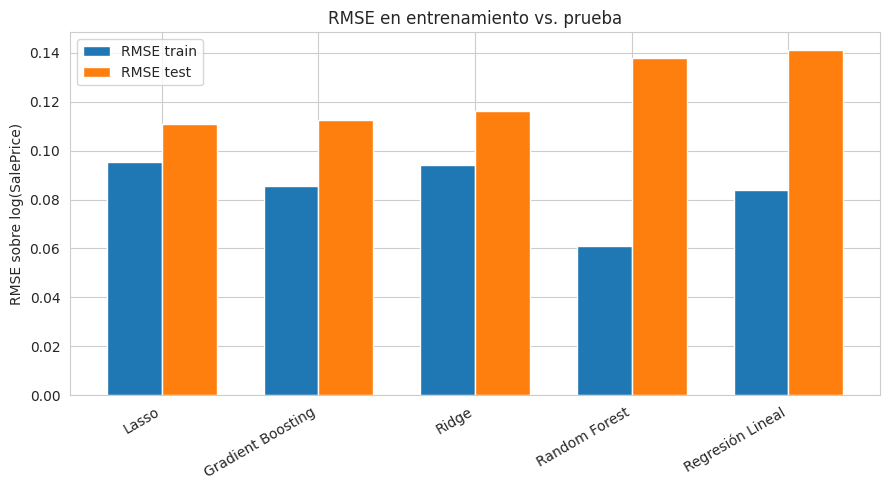

In [13]:
# Gráfico de sesgo/varianza
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(tabla_evaluacion))
width = 0.35

ax.bar(
    x_pos - width/2,
    tabla_evaluacion["RMSE_train"],
    width,
    label="RMSE train"
)
ax.bar(
    x_pos + width/2,
    tabla_evaluacion["RMSE_test"],
    width,
    label="RMSE test"
)

ax.set_xticks(x_pos)
ax.set_xticklabels(tabla_evaluacion.index, rotation=30, ha="right")
ax.set_ylabel("RMSE sobre log(SalePrice)")
ax.set_title("RMSE en entrenamiento vs. prueba")
ax.legend()

plt.tight_layout()
plt.show()


## 6. Interpretación de resultados
- Analizar la importancia de las variables (feature importance).
- Visualizar errores y predicciones (por ejemplo, gráficos de dispersión o matriz de confusión).
- Evaluar si los resultados son coherentes con el contexto del problema.


El modelo con menor `RMSE_test` se interpreta de dos formas:

1. **Variables importantes:**  
   - En modelos lineales se observan los coeficientes.
   - En modelos de árboles se observa `feature_importances_`.

2. **Comportamiento de los errores:**  
   - Predicción vs. valor real.
   - Residuales (`real - predicho`).

Esto permite no quedarnos solamente con un número de RMSE, sino revisar si el modelo se comporta de manera razonable.


Modelo con menor RMSE_test: Lasso


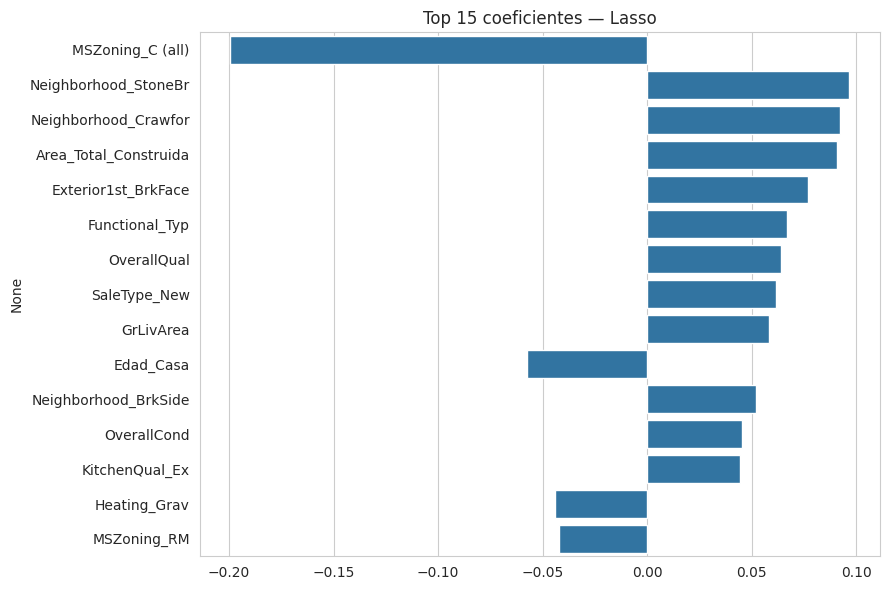

,valor
MSZoning_C (all),-0.199341
Neighborhood_StoneBr,0.096512
Neighborhood_Crawfor,0.092276
Area_Total_Construida,0.090903
Exterior1st_BrkFace,0.076795
Functional_Typ,0.066804
OverallQual,0.063908
SaleType_New,0.061421
GrLivArea,0.058279
Edad_Casa,-0.057311


In [14]:
mejor_nombre = tabla_evaluacion.index[0]
mejor_modelo = modelos_entrenados[mejor_nombre]

print("Modelo con menor RMSE_test:", mejor_nombre)

# Obtener nombres de las variables después del preprocesamiento
feature_names = mejor_modelo.named_steps["prep"].get_feature_names_out()
algoritmo = mejor_modelo.named_steps["model"]

if hasattr(algoritmo, "coef_"):
    valores = algoritmo.coef_
    importancia = (
        pd.Series(valores, index=feature_names)
        .sort_values(key=np.abs, ascending=False)
        .head(15)
    )
    titulo = f"Top 15 coeficientes — {mejor_nombre}"

elif hasattr(algoritmo, "feature_importances_"):
    valores = algoritmo.feature_importances_
    importancia = (
        pd.Series(valores, index=feature_names)
        .sort_values(ascending=False)
        .head(15)
    )
    titulo = f"Top 15 importancias — {mejor_nombre}"

else:
    importancia = None

if importancia is not None:
    plt.figure(figsize=(9, 6))
    sns.barplot(x=importancia.values, y=importancia.index)
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

    display(importancia.to_frame("valor"))


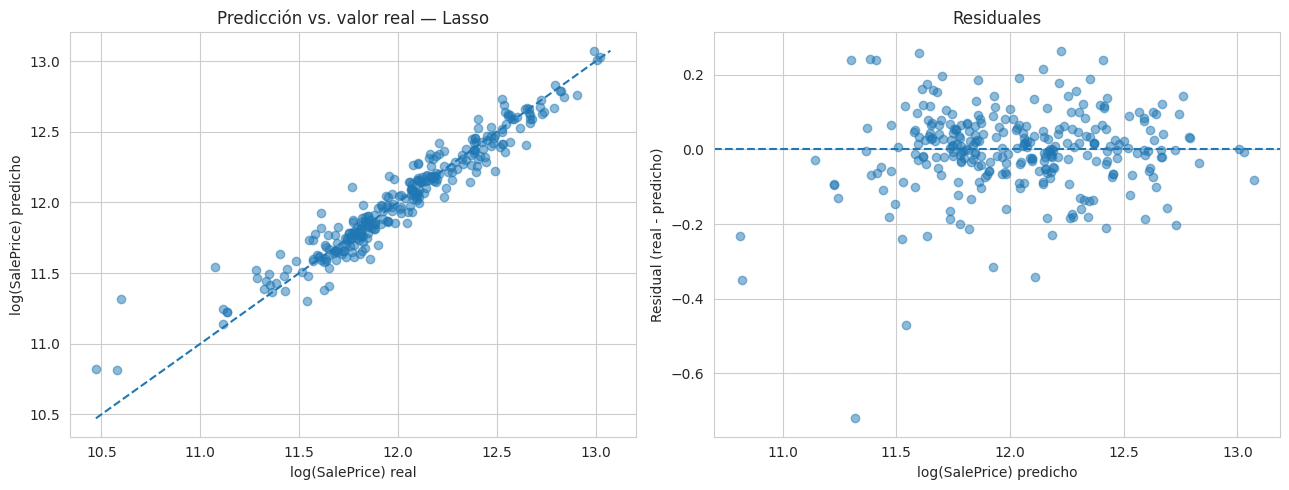

In [15]:
pred_test_mejor = mejor_modelo.predict(X_test)
residuales = y_test - pred_test_mejor

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, pred_test_mejor, alpha=0.5)
lims = [
    min(y_test.min(), pred_test_mejor.min()),
    max(y_test.max(), pred_test_mejor.max())
]
axes[0].plot(lims, lims, linestyle="--")
axes[0].set_xlabel("log(SalePrice) real")
axes[0].set_ylabel("log(SalePrice) predicho")
axes[0].set_title(f"Predicción vs. valor real — {mejor_nombre}")

axes[1].scatter(pred_test_mejor, residuales, alpha=0.5)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("log(SalePrice) predicho")
axes[1].set_ylabel("Residual (real - predicho)")
axes[1].set_title("Residuales")

plt.tight_layout()
plt.show()


## 7. Selección del mejor modelo
- Comparar distintos modelos en función de sus métricas y complejidad.
- Considerar criterios como precisión, interpretabilidad, tiempo de entrenamiento y escalabilidad


La selección final se realiza principalmente con el **RMSE del conjunto de prueba**, porque es la métrica central del proyecto. También se consideran:

- **R²**
- diferencia entre train y test
- interpretabilidad
- complejidad del algoritmo

No se utiliza un *ensemble* como modelo final porque la plantilla solicita comparar y seleccionar modelos; mantener un único algoritmo facilita explicar y justificar el resultado.


In [16]:
interpretabilidad = {
    "Regresión Lineal": "Alta",
    "Ridge": "Alta",
    "Lasso": "Alta",
    "Random Forest": "Media",
    "Gradient Boosting": "Media",
}

resumen_final = tabla_evaluacion.copy()
resumen_final["Interpretabilidad"] = pd.Series(interpretabilidad)
resumen_final["Brecha_train_test"] = (
    resumen_final["RMSE_test"] - resumen_final["RMSE_train"]
)

display(
    resumen_final[
        [
            "RMSE_train",
            "RMSE_test",
            "MAE_test",
            "R2_test",
            "Brecha_train_test",
            "Interpretabilidad",
        ]
    ].round(4)
)

mejor_nombre = resumen_final.index[0]
mejor_modelo = modelos_entrenados[mejor_nombre]

print("\nMODELO SELECCIONADO:", mejor_nombre)
print("RMSE_test:", round(resumen_final.loc[mejor_nombre, "RMSE_test"], 4))
print("R2_test:", round(resumen_final.loc[mejor_nombre, "R2_test"], 4))


,RMSE_train,RMSE_test,MAE_test,R2_test,Brecha_train_test,Interpretabilidad
Lasso,0.0954,0.1108,0.0766,0.9271,0.0155,Alta
Gradient Boosting,0.0854,0.1126,0.0797,0.9247,0.0273,Media
Ridge,0.0941,0.1163,0.0781,0.9198,0.0222,Alta
Random Forest,0.0610,0.1379,0.0915,0.8873,0.0769,Media
Regresión Lineal,0.0839,0.1413,0.0902,0.8816,0.0574,Alta



MODELO SELECCIONADO: Lasso
RMSE_test: 0.1108
R2_test: 0.9271


## 8. Experimento complementario: periodo de crisis 2008–2010

Este apartado se agrega porque en el documento de preparación se propuso comprobar si retirar las ventas de 2008–2010 podía mejorar el desempeño.

No se eliminan estos años automáticamente. Se prueba la hipótesis de forma experimental:

- **Escenario A:** entrenar con todos los años.
- **Escenario B:** retirar del entrenamiento las observaciones con `YrSold >= 2008`.
- Ambos modelos se evalúan sobre **el mismo fold de validación**, para que la comparación sea justa.

Si el RMSE aumenta al retirar 2008–2010, significa que eliminar esos datos perjudica la capacidad predictiva y se justifica conservarlos.


In [17]:
# Usamos el algoritmo seleccionado en la sección 7.
# El experimento se realiza únicamente sobre X_train / y_train,
# sin tocar el holdout X_test.

kf_crisis = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_crisis = []

for fold, (idx_tr, idx_val) in enumerate(kf_crisis.split(X_train), start=1):
    X_tr = X_train.iloc[idx_tr].copy()
    y_tr = y_train.iloc[idx_tr].copy()
    X_val = X_train.iloc[idx_val].copy()
    y_val = y_train.iloc[idx_val].copy()

    # A) Todos los años
    modelo_todos = clone(mejor_modelo)
    modelo_todos.fit(X_tr, y_tr)
    pred_todos = modelo_todos.predict(X_val)
    rmse_todos = root_mean_squared_error(y_val, pred_todos)

    # B) Entrenar sin 2008-2010, pero validar sobre el mismo X_val
    mascara_precrisis = X_tr["YrSold"] < 2008

    modelo_sin_crisis = clone(mejor_modelo)
    modelo_sin_crisis.fit(
        X_tr.loc[mascara_precrisis],
        y_tr.loc[mascara_precrisis]
    )
    pred_sin_crisis = modelo_sin_crisis.predict(X_val)
    rmse_sin_crisis = root_mean_squared_error(
        y_val,
        pred_sin_crisis
    )

    resultados_crisis.append({
        "Fold": fold,
        "RMSE_todos_los_años": rmse_todos,
        "RMSE_sin_2008_2010": rmse_sin_crisis,
    })

crisis_df = pd.DataFrame(resultados_crisis)
display(crisis_df.round(4))

promedios_crisis = crisis_df[
    ["RMSE_todos_los_años", "RMSE_sin_2008_2010"]
].mean()

print("\nPromedio CV:")
print(promedios_crisis.round(4))

if promedios_crisis["RMSE_todos_los_años"] < promedios_crisis["RMSE_sin_2008_2010"]:
    print("\nConclusión: conservar 2008–2010 produce menor error.")
else:
    print("\nConclusión: retirar 2008–2010 produce menor error.")


,Fold,RMSE_todos_los_años,RMSE_sin_2008_2010
0,1,0.1259,0.1307
1,2,0.1013,0.1121
2,3,0.0998,0.1058
3,4,0.1104,0.1186
4,5,0.1151,0.1319



Promedio CV:
RMSE_todos_los_años    0.1105
RMSE_sin_2008_2010     0.1198
dtype: float64

Conclusión: conservar 2008–2010 produce menor error.


## 9. Generación del archivo de predicciones para Kaggle

Después de seleccionar el algoritmo:

1. Se vuelve a entrenar el modelo elegido utilizando **todas las 1,458 observaciones limpias** disponibles.
2. Se predicen las 1,459 viviendas de `test_clean.csv`.
3. Como el modelo trabaja con `log1p(SalePrice)`, se aplica `expm1()` para regresar las predicciones a dólares.
4. Se genera `submission.csv` con las dos columnas exigidas: `Id` y `SalePrice`.

Este archivo corresponde a la etapa de despliegue y no se utiliza para elegir el modelo, porque Kaggle no proporciona los precios reales de `test.csv`.


In [18]:
# Reentrenar el modelo seleccionado con TODO el train limpio
modelo_final = clone(mejor_modelo)
modelo_final.fit(X, y_log)

# Predicción del test oficial
pred_log_kaggle = modelo_final.predict(X_kaggle)
pred_saleprice = np.expm1(pred_log_kaggle)

submission = pd.DataFrame({
    "Id": ids_test,
    "SalePrice": pred_saleprice
})

# Validaciones simples
assert submission.shape[0] == 1459
assert submission["SalePrice"].isna().sum() == 0

submission.to_csv("submission.csv", index=False)

print("Archivo generado: submission.csv")
print("Forma:", submission.shape)
display(submission.head())


Archivo generado: submission.csv
Forma: (1459, 2)


,Id,SalePrice
0,1461,117117.281335
1,1462,153235.056970
2,1463,180344.978977
3,1464,202156.694316
4,1465,192110.052005
